In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 73.0 MB/s eta 0:00:00


In [4]:
import zipfile
import os

# Corrected path: the archive.zip is in /content/, not in Google Drive
zip_path = "/content/archive.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [5]:
import os

for root, dirs, files in os.walk("/content/dataset"):
    print(root)
    if len(files) > 0:
        print("Files:", files[:5])

/content/dataset
/content/dataset/results_yolov8n_100e
/content/dataset/results_yolov8n_100e/kaggle
/content/dataset/results_yolov8n_100e/kaggle/working
Files: ['yolov8n.pt', 'ppe_data.yaml', '__notebook__.ipynb']
/content/dataset/results_yolov8n_100e/kaggle/working/runs
/content/dataset/results_yolov8n_100e/kaggle/working/runs/detect
/content/dataset/results_yolov8n_100e/kaggle/working/runs/detect/train
Files: ['confusion_matrix.png', 'val_batch0_pred.jpg', 'val_batch1_labels.jpg', 'train_batch0.jpg', 'val_batch2_pred.jpg']
/content/dataset/results_yolov8n_100e/kaggle/working/runs/detect/train/weights
Files: ['last.pt', 'best.pt']
/content/dataset/css-data
Files: ['README.roboflow.txt', 'README.dataset.txt']
/content/dataset/css-data/test
/content/dataset/css-data/test/labels
Files: ['2009_000496_jpg.rf.9a2d210fe0f5ea4b572aeb07e41ecbae.txt', 'autox3_mp4-65_jpg.rf.d933ce48947fa9bdb55dc702a0879ac9.txt', 'ppe_1073_jpg.rf.72ea8a293a4f3e1135219e33701b1099.txt', 'image_55_jpg.rf.27ae4341a9b

In [6]:
%%writefile /content/ppe.yaml

path: /content/dataset/css-data

train: train/images
val: valid/images
test: test/images

names:
  0: Hardhat
  1: Mask
  2: NO-Hardhat
  3: NO-Mask
  4: NO-Safety Vest
  5: Person
  6: Safety Cone
  7: Safety Vest
  8: machinery
  9: vehicle

Writing /content/ppe.yaml


In [7]:
from ultralytics import YOLO

print("Dataset configuration created successfully.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Dataset configuration created successfully.


In [8]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="/content/ppe.yaml",
    epochs=50,
    imgsz=640,
    batch=16
)

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ppe.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective

In [9]:
metrics = model.val()

print(metrics)

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2199.3±669.6 MB/s, size: 56.0 KB)
val: Scanning /content/dataset/css-data/valid/labels.cache... 114 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 114/114 31.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.9it/s 4.1s
                   all        114        697      0.892      0.687      0.779      0.461
               Hardhat         42         79      0.967      0.744      0.866      0.553
                  Mask         19         21      0.951       0.81      0.918      0.626
            NO-Hardhat         37         69      0.936      0.522      0.674      0.352
               NO-Mask         44         74      0.949      0.541      0.634      0.291
        NO-Safety Vest         56        

In [10]:
results = model.predict(
    source="/content/dataset/css-data/test/images",
    conf=0.25,
    save=True
)


image 1/82 /content/dataset/css-data/test/images/-4405-_png_jpg.rf.82b5c10b2acd1cfaa24259ada8e599fe.jpg: 640x640 1 Hardhat, 1 NO-Safety Vest, 1 Person, 7.2ms
image 2/82 /content/dataset/css-data/test/images/000005_jpg.rf.96e9379ccae638140c4a90fc4b700a2b.jpg: 640x640 2 Hardhats, 2 NO-Masks, 4 Persons, 1 vehicle, 7.3ms
image 3/82 /content/dataset/css-data/test/images/002551_jpg.rf.ce4b9f934161faa72c80dc6898d37b2d.jpg: 640x640 2 Hardhats, 1 NO-Mask, 3 NO-Safety Vests, 4 Persons, 8.2ms
image 4/82 /content/dataset/css-data/test/images/003357_jpg.rf.9867f91e88089bb68dc95947d5116d14.jpg: 640x640 1 Hardhat, 1 NO-Mask, 1 NO-Safety Vest, 1 Person, 1 Safety Cone, 7.3ms
image 5/82 /content/dataset/css-data/test/images/004063_jpg.rf.1b7cdc4035bcb24ef69b8798b444053e.jpg: 640x640 6 Hardhats, 4 NO-Safety Vests, 6 Persons, 2 Safety Vests, 7.2ms
image 6/82 /content/dataset/css-data/test/images/004763_jpg.rf.46484e6ca73caeaa9de45822cf1085a9.jpg: 640x640 3 Hardhats, 2 NO-Masks, 3 NO-Safety Vests, 3 Perso

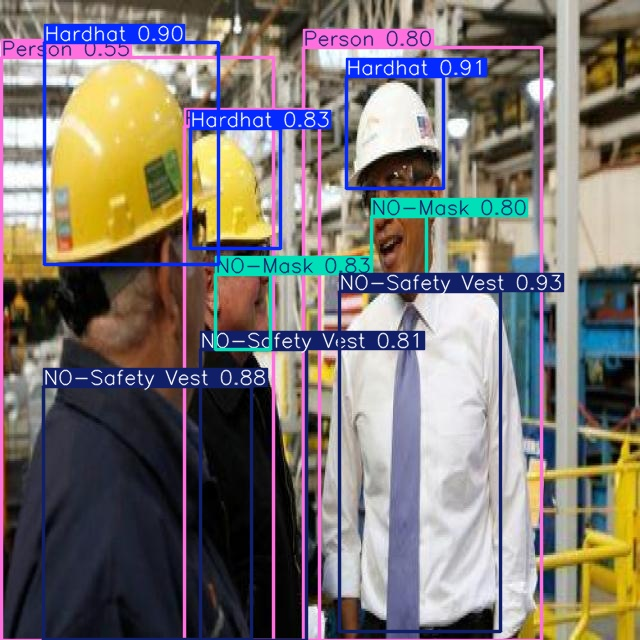

In [26]:
from IPython.display import Image, display
import glob

result_images = glob.glob("/content/runs/detect/predict/*.jpg")

display(Image(filename=result_images[0]))

In [28]:
import shutil

shutil.copy(
    "/content/runs/detect/train/weights/best.pt",
    "/content/drive/MyDrive/best.pt"
)

print("Model saved to Google Drive!")

Model saved to Google Drive!


In [29]:
from google.colab import files

uploaded = files.upload()

Saving constru.jpg to constru (2).jpg


In [30]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/best.pt")

results = model.predict(
    source=list(uploaded.keys())[0],
    conf=0.25,
    save=True
)


image 1/1 /content/constru (2).jpg: 448x640 1 Hardhat, 1 NO-Mask, 1 Person, 1 Safety Vest, 9.0ms
Speed: 2.5ms preprocess, 9.0ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict-5


Prediction files: ['/content/runs/detect/predict-3/constru.jpg', '/content/runs/detect/predict-5/constru (2).jpg', '/content/runs/detect/predict-2/h (1).jpg', '/content/runs/detect/predict-4/constru (1).jpg', '/content/runs/detect/predict/004763_jpg.rf.46484e6ca73caeaa9de45822cf1085a9.jpg', '/content/runs/detect/predict/IMG_3103_mp4-9_jpg.rf.b31bd2d816465a27aa1eb072f90bb5aa.jpg', '/content/runs/detect/predict/youtube-596_jpg.rf.11a8a4ac01d8aadb80eeb0406dfa579a.jpg', '/content/runs/detect/predict/autox3_mp4-65_jpg.rf.d933ce48947fa9bdb55dc702a0879ac9.jpg', '/content/runs/detect/predict/2008_008519_jpg.rf.1798c8eed7de04399a0e7e297b4b4c9e.jpg', '/content/runs/detect/predict/class1_150_jpg.rf.5995dce34d38deb9eb0b6e36cae78f17.jpg', '/content/runs/detect/predict/construction-2-_mp4-13_jpg.rf.cef0975976346515d438e0c2ce6c59db.jpg', '/content/runs/detect/predict/youtube-34_jpg.rf.03eacc444bae3c5caa3fef5c736c3e40.jpg', '/content/runs/detect/predict/2008_008320_jpg.rf.bd34011d46f82f9410d95f00e560b

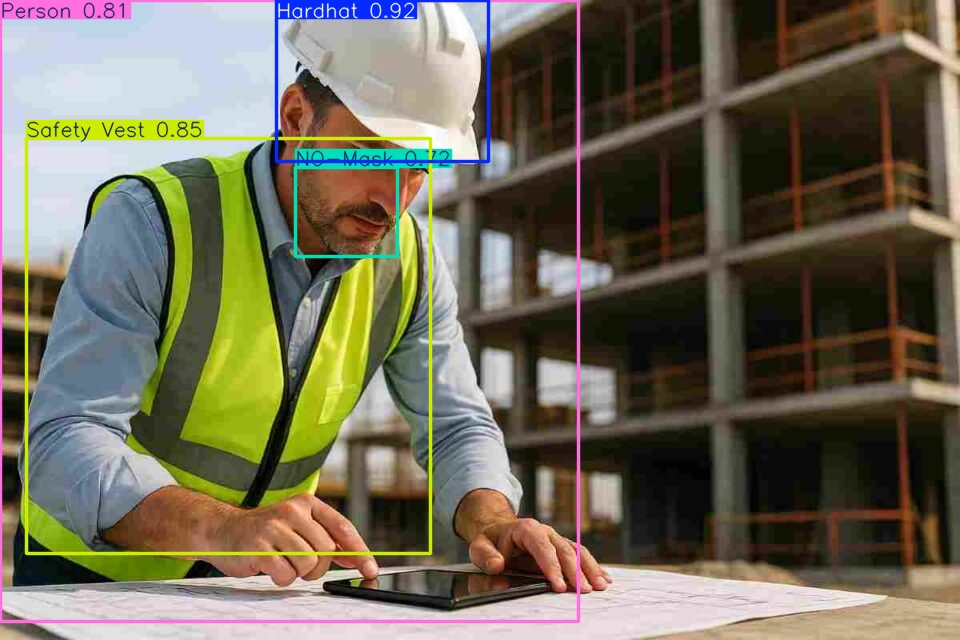

In [32]:
from IPython.display import Image, display
import glob

# Find predicted images
result_images = glob.glob("/content/runs/detect/predict*/*")

print("Prediction files:", result_images)

# Display first prediction
if len(result_images) > 0:
    display(Image(filename=result_images[0]))
else:
    print("No prediction image found!")